In [76]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing


In [77]:
data = fetch_california_housing()

In [78]:
df = pd.DataFrame(data = data.data , columns = data.feature_names)


In [79]:
df['Price'] = data.target

In [80]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [81]:
df.shape

(20640, 9)

In [82]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [83]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

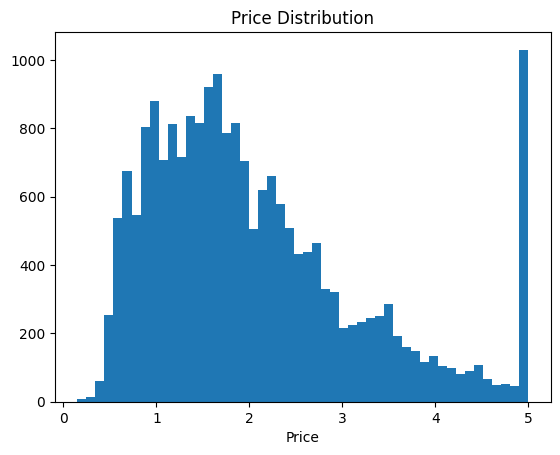

In [84]:
plt.hist(df['Price'],bins=50)
plt.xlabel('Price')
plt.title('Price Distribution')
plt.show()


Observation 1: Most house prices are concentrated between $100k-$300k
Observation 2: Distribution is right-skewed — more cheap houses than expensive ones
Observation 3: There is an artificial cap at $500k — houses above this price 
were all recorded as 5.0, which may affect model accuracy

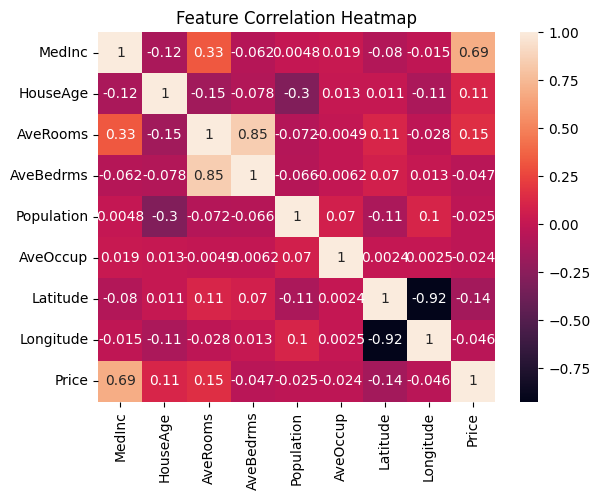

In [85]:
sns.heatmap(df.corr(),annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

Observation 4: MedInc has highest correlation with Price (0.69) — 
richer neighborhoods have more expensive houses. Makes sense.

Observation 5: Latitude and Longitude have low correlation with Price 
individually but location still matters — we'll keep them.

Observation 6: AveRooms and AveBedrms are highly correlated with each other.
This is called multicollinearity. They carry similar information.

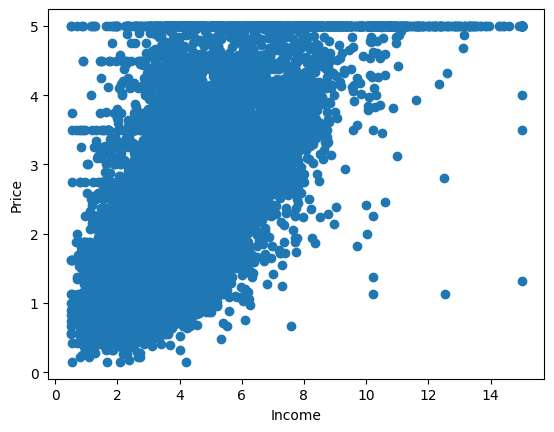

In [86]:
plt.scatter(x=df['MedInc'] , y=df['Price'])
plt.xlabel('Income')
plt.ylabel('Price')
plt.show()

Observation 7: Clear positive relationship between MedInc and Price.
Higher income neighborhoods = more expensive houses.
The flat line at Price=5.0 confirms the artificial price cap we noticed earlier.

<function matplotlib.pyplot.show(close=None, block=None)>

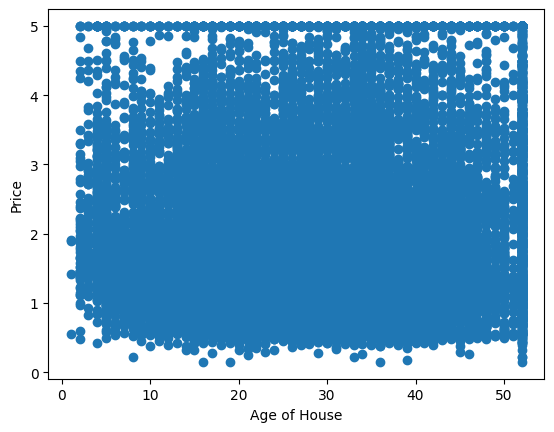

In [87]:
plt.scatter(x=df['HouseAge'] , y=df['Price'])
plt.xlabel('Age of House')
plt.ylabel('Price')
plt.show

Observation 8: House age has very weak relationship with Price.
Age alone is not a good predictor of house price.
MedInc is clearly the most important feature so far.

In [88]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2 , random_state = 20)

In [91]:

X_train.shape

(16512, 8)

In [92]:
y_train.shape

(16512,)

In [93]:
X_test.shape

(4128, 8)

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [95]:
pipeline_steps=[
        ('scaler' , StandardScaler()),
        ('model' , LinearRegression())
]

In [96]:
housing_pipeline= Pipeline(pipeline_steps)

In [97]:
housing_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [98]:
y_pred = housing_pipeline.predict(X_test)

In [99]:
from sklearn.metrics import mean_absolute_error,  mean_squared_error , root_mean_squared_error , r2_score

In [100]:
print("MSE", mean_squared_error(y_test,y_pred))
print("MAE" , mean_absolute_error(y_test,y_pred))
print("RMSE", root_mean_squared_error(y_test,y_pred))
print("r2Score",r2_score(y_test,y_pred))

MSE 0.5410055769085322
MAE 0.5409622217186032
RMSE 0.7355308130245342
r2Score 0.6121654293404898


Model Results:
- R² Score: 0.61 — model explains 61% of price variation
- RMSE: 0.73 — average prediction error of $73,000
- Linear Regression is a baseline model
- Score can be improved with better feature engineering 
  or more powerful models like Random Forest

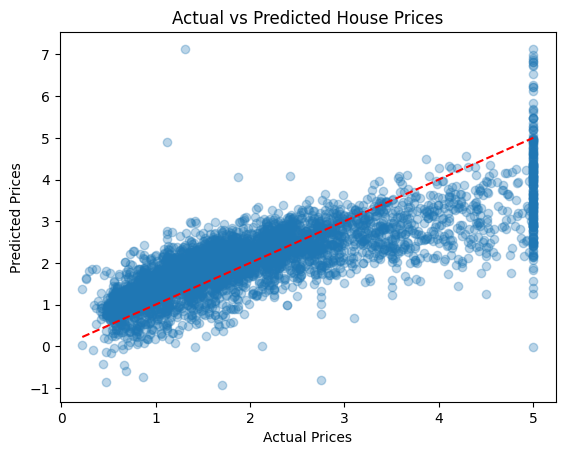

In [102]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--')
plt.show()

Observation 9: Model performs well for mid-range prices (1-3)
but struggles with expensive houses above $400k.
This is partly due to the artificial price cap at $500k in the dataset.

## Project Summary

**Goal:** Predict California house prices using Linear Regression

**Dataset:** California Housing Dataset (20,640 rows, 8 features)

**Key Findings from EDA:**
- MedInc (median income) is the strongest predictor of house price
- House age has very weak relationship with price
- Dataset has an artificial price cap at $500k

**Model Performance:**
- R² Score: 0.61
- RMSE: $73,000
- MAE: $54,000

**Conclusion:** 
Linear Regression gives a decent baseline. 
Model can be improved using Random Forest or XGBoost.